# Drogued drifter in synthetic sheared flow

We test the `DroguedDrifter` with a simple, analytically defined velocity
profile: uniform flow at the surface, weaker (or reversed) flow at drogue depth.
This lets us verify the drifter behaviour without any external data dependencies.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from drogued_drifters import DroguedDrifter
from drogued_drifters.drifter import (
    drogue_added_mass,
    buoy_added_mass,
    drogue_drag_coeff,
    buoy_drag_coeff,
)

## Define a synthetic velocity profile

Surface current is 1 m/s eastward and 0.5 m/s northward. At drogue depth, the
current rotates and weakens: it decays exponentially (e-folding scale 2 m) and
shifts southward. This vertical shear means a drogued drifter should drift
differently from a surface-only buoy.

In [2]:
def sheared_uv(*, t, z_d, y_b, x_b):
    """Surface current with depth decay and rotation."""
    U_b, V_b = 1.0, 0.5
    factor = np.exp(-abs(z_d) / 2.0)
    U_d = U_b * factor
    V_d = -0.3 * factor
    return U_b, V_b, U_d, V_d

## Physical parameters

Drifter geometry based on Callies et al.: drogue is a cross of two 0.5 m x 0.5 m
aluminium plates, buoy is a cylinder (diameter 0.1 m, submerged height 0.24 m),
connected by a 3 m pole.

In [3]:
rho = 1025.0  # sea water density [kg/m^3]

# drogue: cross of two plates
w_d, h_d, t_d = 0.5, 0.5, 0.002  # width, height, thickness [m]
rho_d = 2700.0  # aluminium density [kg/m^3]
m_d = 2 * rho_d * w_d * h_d * t_d  # two plates
m_hat_d = 2 * rho * w_d * h_d * t_d  # displaced water mass

# buoy: cylinder
d_b, h_b = 0.1, 0.24  # diameter, submerged height [m]
m_b = 1.0  # kg

drifter_params = dict(
    m_b=m_b,
    m_d=m_d,
    m_hat_d=m_hat_d,
    m_tilde_d=drogue_added_mass(rho=rho, w_d=w_d, h_d=h_d),
    m_tilde_b=buoy_added_mass(rho=rho, d_b=d_b, h_b=h_b),
    l=3.0,
    k_b=buoy_drag_coeff(rho=rho, d_b=d_b, h_b=h_b),
    k_d=drogue_drag_coeff(rho=rho, w_d=w_d, h_d=h_d),
)

## Set up two drifters

We compare a **complete drifter** against a **buoy-only** drifter (negligible
drogue mass, drag, and added mass). The buoy-only case should simply follow the
surface current.

In [4]:
drifter_complete = DroguedDrifter(**drifter_params, get_uv=sheared_uv)

buoy_only_params = {
    **drifter_params,
    "m_d": 0.01,
    "m_hat_d": 0.0,
    "m_tilde_d": 0.0,
    "k_d": 0.01,
}
drifter_buoy = DroguedDrifter(**buoy_only_params, get_uv=sheared_uv)

In [5]:
T = 120.0
dt = 1.0
t_eval = np.arange(0.0, T + dt, dt)

In [6]:
ds_complete = drifter_complete.get_full_solution(
    t_span=(0, T),
    theta=3 * np.pi / 4,
    t_eval=t_eval,
)
ds_buoy = drifter_buoy.get_full_solution(
    t_span=(0, T),
    theta=3 * np.pi / 4,
    t_eval=t_eval,
)

ds_complete

<xarray.Dataset> Size: 9kB
Dimensions:  (time: 121)
Coordinates:
  * time     (time) float64 968B 0.0 1.0 2.0 3.0 4.0 ... 117.0 118.0 119.0 120.0
Data variables:
    x        (time) float64 968B 0.0 1.38 2.753 3.339 ... 50.41 50.82 51.23
    y        (time) float64 968B 0.0 0.2715 0.4784 0.5526 ... 6.702 6.753 6.806
    theta    (time) float64 968B 2.356 2.866 2.888 2.74 ... 2.755 2.756 2.755
    phi      (time) float64 968B 0.0 -0.3598 -2.413 ... -2.488 -2.488 -2.488
    xd       (time) float64 968B 0.0 1.757 0.9316 ... 0.4131 0.4166 0.4152
    yd       (time) float64 968B 0.0 0.3353 0.06473 ... 0.05069 0.05342 0.05228
    thetad   (time) float64 968B 0.0 0.5179 -0.23 ... -0.00085 -0.0001847
    phid     (time) float64 968B 0.0 -1.156 -0.6987 ... 1.048e-06 4.387e-08

## Trajectories

The buoy-only drifter follows the surface current. The complete drifter is
slowed down by the drogue experiencing weaker flow at depth.

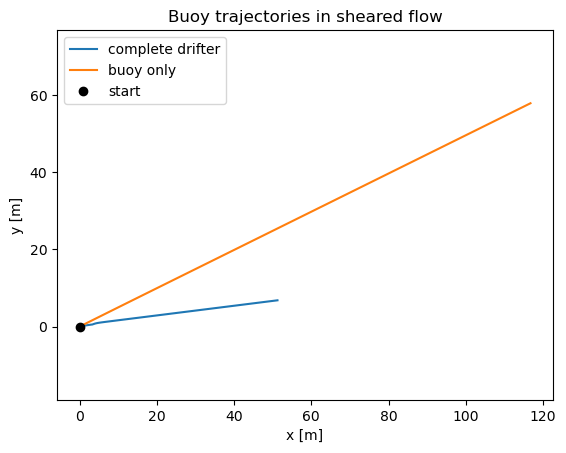

In [7]:
plt.plot(ds_complete.x, ds_complete.y, label="complete drifter")
plt.plot(ds_buoy.x, ds_buoy.y, label="buoy only")
plt.plot(0, 0, "ko", label="start")
plt.axis("equal")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.legend()
plt.title("Buoy trajectories in sheared flow")
plt.show()

## Tether angle over time

The tether angle `theta` should settle from its initial value (135°) to a
steady state near 180° (drogue hanging below the buoy, slightly deflected
by shear).

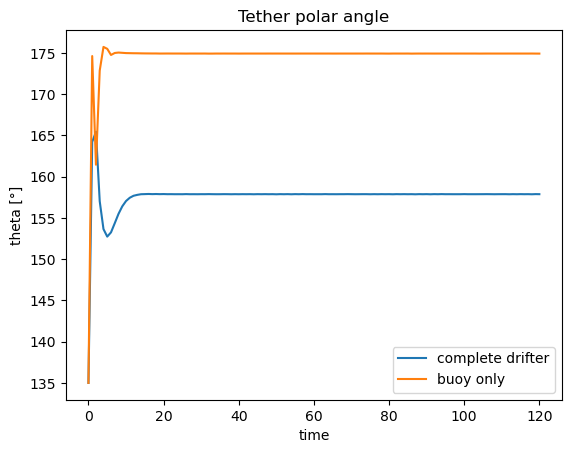

In [8]:
(ds_complete.theta * 180 / np.pi).plot(label="complete drifter")
(ds_buoy.theta * 180 / np.pi).plot(label="buoy only")
plt.ylabel("theta [°]")
plt.legend()
plt.title("Tether polar angle")
plt.show()